# Dataset Description: Diabetes Health Indicators

This dataset contains health indicators to predict diabetes status (0: no diabetes, 1: pre-diabetes, 2: diabetes).

**Key Features and Typical Value Ranges/Categories:**

*   **`Diabetes_012`**: Target variable (0, 1, 2).
*   **`HighBP`**: High Blood Pressure (0=no, 1=yes).
*   **`HighChol`**: High Cholesterol (0=no, 1=yes).
*   **`CholCheck`**: Cholesterol check in past 5 years (0=no, 1=yes).
*   **`BMI`**: Body Mass Index (continuous).
*   **`Smoker`**: Smoked 100+ cigarettes in lifetime (0=no, 1=yes).
*   **`Stroke`**: Ever had a stroke (0=no, 1=yes).
*   **`HeartDiseaseorAttack`**: Ever had coronary heart disease/MI (0=no, 1=yes).
*   **`PhysActivity`**: Physical activity in past 30 days (0=no, 1=yes).
*   **`Fruits`**: Consumes fruit 1+ times/day (0=no, 1=yes).
*   **`Veggies`**: Consumes vegetables 1+ times/day (0=no, 1=yes).
*   **`HvyAlcoholConsump`**: Heavy alcohol consumption (0=no, 1=yes).
*   **`AnyHealthcare`**: Has healthcare coverage (0=no, 1=yes).
*   **`NoDocbcCost`**: Unable to see doctor due to cost (0=no, 1=yes).
*   **`GenHlth`**: General Health (1=excellent to 5=poor).
*   **`MentHlth`**: Days with poor mental health (0-30).
*   **`PhysHlth`**: Days with poor physical health (0-30).
*   **`DiffWalk`**: Difficulty walking/climbing stairs (0=no, 1=yes).
*   **`Sex`**: (0=female, 1=male).
*   **`Age`**: Age category (1=18-24, 13=80+).
*   **`Education`**: Education level (1=never attended to 6=college graduate).
*   **`Income`**: Income level (1=<10,000 to 8=75,000+).

This dataset is suitable for classification tasks to predict diabetes.

## Setup: Import Libraries and Tools

The following Python cell imports the necessary libraries for data loading, preprocessing, train/test splitting, and oversampling.

*   `pandas` for data handling and exploration.
*   `train_test_split` from `sklearn.model_selection` to create a clean separation between training and test data.
*   `SMOTE` from `imblearn.over_sampling` to balance the minority classes in the training set.
*   `StandardScaler` and `MinMaxScaler` from `sklearn.preprocessing` for feature scaling.
*   `ColumnTransformer` from `sklearn.compose` to apply transformations to specific columns.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer


### Step 1: Load the Data & Define Target/Features
We begin by loading the dataset. We are using the original 3-class target variable (`Diabetes_012`).
* `X` represents our features (the patient's health clues).
* `y` represents our target (the patient's actual diagnosis).

In [2]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

# We are using (Multiclass: 0, 1, 2)
y = df['Diabetes_012']
X = df.drop(columns=['Diabetes_012'])

print("Step 1 Complete: X and y are defined.")


Step 1 Complete: X and y are defined.


### Step 2: The Train/Test Split - Securing Our Evaluation

To ensure unbiased model evaluation, we split our data into training (80%) and testing (20%) sets. This is done *before* any data manipulation to prevent data leakage. We use `stratify=y` to maintain the target variable's class proportions in both sets, crucial for our imbalanced dataset.

In [3]:

# Split the Data safely
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Step 2 Complete: Data is successfully split!")
print(f"Training data has {X_train.shape[0]} patients.")
print(f"Testing data has {X_test.shape[0]} patients.")


Step 2 Complete: Data is successfully split!
Training data has 202944 patients.
Testing data has 50736 patients.


### Step 3: Handling Class Imbalance (SMOTE)

Our dataset is imbalanced (skewed towards 'Healthy' patients). To prevent models from ignoring minority classes, we apply **SMOTE** (Synthetic Minority Over-sampling Technique) *only* to the training data. SMOTE generates synthetic samples for minority classes (Prediabetes, Diabetes) to equalize their representation, ensuring models learn from all patient groups.

In [4]:

smote = SMOTE(random_state=42)

print("Applying SMOTE... (this might take a few seconds on a large dataset)")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\n--- BEFORE SMOTE: Training Set Class Counts ---")
print(y_train.value_counts())

print("\n--- AFTER SMOTE: Training Set Class Counts ---")
print(y_train_resampled.value_counts())

# Let's double check that the test set was left entirely alone
print("\n--- untouched Test Set Class Counts (Real World) ---")
print(y_test.value_counts())


Applying SMOTE... (this might take a few seconds on a large dataset)

--- BEFORE SMOTE: Training Set Class Counts ---
Diabetes_012
0.0    170962
2.0     28277
1.0      3705
Name: count, dtype: int64

--- AFTER SMOTE: Training Set Class Counts ---
Diabetes_012
0.0    170962
2.0    170962
1.0    170962
Name: count, dtype: int64

--- untouched Test Set Class Counts (Real World) ---
Diabetes_012
0.0    42741
2.0     7069
1.0      926
Name: count, dtype: int64


#### SMOTE Results: A Balanced Training Landscape

SMOTE successfully balanced the training set: minority classes (Prediabetes, Diabetes) now have equal representation with 'Healthy' patients. Crucially, the test set remains untouched, preserving its real-world class distribution for unbiased evaluation.

### Step 4: Feature Scaling (Leveling the Playing Field)
Different features have wildly different scales (e.g., BMI ranges from 15 to 90+, while Smoker is 0 or 1). We use a `ColumnTransformer` to apply specific math to specific columns so no single feature unfairly dominates the model:
1. **Binary:** Left completely alone (`passthrough`).
2. **Ordinal:** Squashed into a percentage between 0 and 1 (`MinMaxScaler`).
3. **Continuous (BMI):** Converted to a Z-Score representing distance from the average (`StandardScaler`).

The `ColumnTransformer` applies specific scaling: `passthrough` for binary features, `MinMaxScaler` for ordinal, and `StandardScaler` for continuous (`BMI`). Scaling parameters are fitted *only* on the training data and then applied to both training and test sets to prevent data leakage.

In [5]:

# 1. Group the columns by type
binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
               'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
               'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
               'Sex', 'DiffWalk']

ordinal_cols = ['GenHlth', 'Age', 'Education', 'Income', 'MentHlth', 'PhysHlth']

continuous_cols = ['BMI']

# 2. Build the Transformer rules
preprocessor = ColumnTransformer(transformers=[
    ('binary', 'passthrough', binary_cols),                  # Do nothing
    ('ordinal', MinMaxScaler(), ordinal_cols),                 # Scale to 0-1
    ('continuous', StandardScaler(), continuous_cols)          # Center around 0
])

print("Scaling data... (this applies the math to hundreds of thousands of rows)")

# 3. FIT on the training data, then TRANSFORM the training data
X_train_scaled = preprocessor.fit_transform(X_train_resampled)

# 4. ONLY TRANSFORM the testing data (No peeking!)
X_test_scaled = preprocessor.transform(X_test)

# Convert back to a DataFrame just so it's easy for us to read/look at
X_train_scaled = pd.DataFrame(X_train_scaled, columns=binary_cols + ordinal_cols + continuous_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=binary_cols + ordinal_cols + continuous_cols)

print("\nStep 4 Complete: All features are scaled!")
print("\n--- A peek at our beautifully scaled Training Data ---")
display(X_train_scaled.head())



Scaling data... (this applies the math to hundreds of thousands of rows)

Step 4 Complete: All features are scaled!

--- A peek at our beautifully scaled Training Data ---


,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,...,NoDocbcCost,Sex,DiffWalk,GenHlth,Age,Education,Income,MentHlth,PhysHlth,BMI
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.25,0.750000,0.6,0.428571,0.0,0.000000,-0.732453
1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.00,0.000000,0.8,0.571429,0.0,0.000000,0.982002
2,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.25,0.833333,0.8,0.285714,0.0,0.000000,0.696260
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.25,0.166667,0.6,0.714286,0.0,0.166667,-0.446710
4,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.50,0.666667,0.6,0.428571,0.1,0.000000,-0.303839


C:\Users\my pc\AppData\Local\Temp\ipykernel_19212\1546468139.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Diabetes_012'], ax=axes[0], palette='viridis')
C:\Users\my pc\AppData\Local\Temp\ipykernel_19212\1546468139.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, ax=axes[1], palette="viridis")


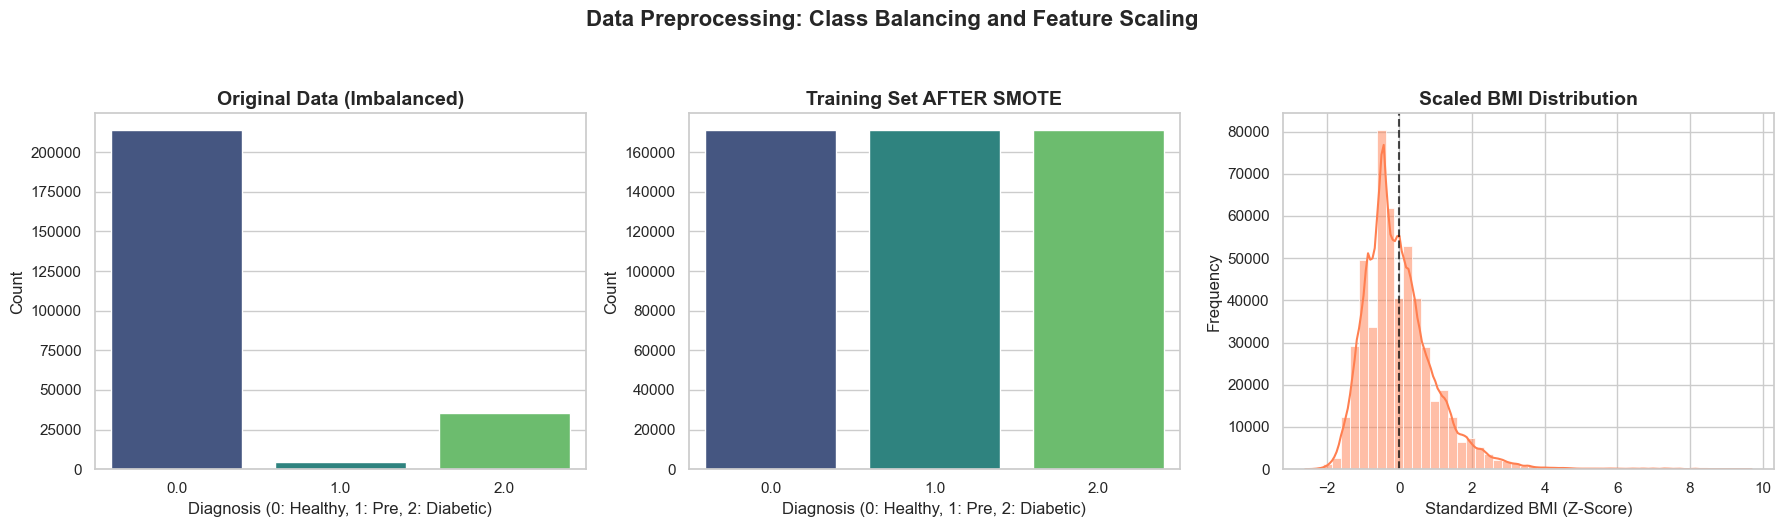

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for professional-looking plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots side-by-side to fit all visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Data Preprocessing: Class Balancing and Feature Scaling', fontsize=16, fontweight='bold', y=1.05)

# Plot 1: Original distribution (from the full DataFrame)
sns.countplot(x=df['Diabetes_012'], ax=axes[0], palette='viridis')
axes[0].set_title('Original Data (Imbalanced)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis (0: Healthy, 1: Pre, 2: Diabetic)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Plot 2: Visualizing SMOTE (Class Balance)
sns.countplot(x=y_train_resampled, ax=axes[1], palette="viridis")
axes[1].set_title("Training Set AFTER SMOTE", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Diagnosis (0: Healthy, 1: Pre, 2: Diabetic)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

# Plot 3: Visualizing StandardScaler (BMI)
sns.histplot(X_train_scaled['BMI'], bins=50, kde=True, ax=axes[2], color="coral")
axes[2].set_title("Scaled BMI Distribution", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Standardized BMI (Z-Score)", fontsize=12)
axes[2].set_ylabel("Frequency", fontsize=12)

# Optional: Add a vertical line at 0 to show the Z-score mean for BMI
axes[2].axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Adjust layout to prevent overlapping text and display
plt.tight_layout()
plt.show()

### Summary & Verdict on Further Preprocessing

#### Normalization (Feature Scaling):

*   **Status**: Already completed. `StandardScaler` (continuous) and `MinMaxScaler` (ordinal) were applied, crucial for algorithms sensitive to feature scales.

#### Binning:

*   **Status**: Not explicitly implemented for `BMI`, `MentHlth`, `PhysHlth`. They remain continuous.
*   **Necessity**: Not strictly necessary currently. While binning can simplify and aid interpretability, it also loses information. Modern models (e.g., tree-based) handle continuous variables well, making it an optional optimization if revisited later.

#### Overall Verdict:

Our data is **well-prepared for Machine Learning Model Training**. We have: data loaded, duplicates handled, types optimized, data split (stratified), imbalance addressed (SMOTE), and features scaled. The dataset (`X_train_scaled`, `X_test_scaled`, `y_train_resampled`, `y_test`) is ready for model building and evaluation.

### Step 5: Exploratory Data Analysis (EDA) - Unveiling Data Patterns

EDA helps us understand dataset characteristics, patterns, relationships, and anomalies. Through visualizations and statistics, we aim to:

*   Understand feature distributions.
*   Identify relationships between features and the target (`Diabetes_012`).
*   Detect outliers.
*   Inform potential feature engineering.

This step builds intuition crucial for model selection and interpretation.

#### Visualizing Key Feature Distributions & Correlations

We visualize distributions of `BMI`, `MentHlth`, and `PhysHlth` to understand their spread. A **correlation heatmap** for key numerical features will then reveal linear relationships, helping identify redundant features or dependencies influencing diabetes status.

--- GENERATING HEALTH DISTRIBUTIONS ---


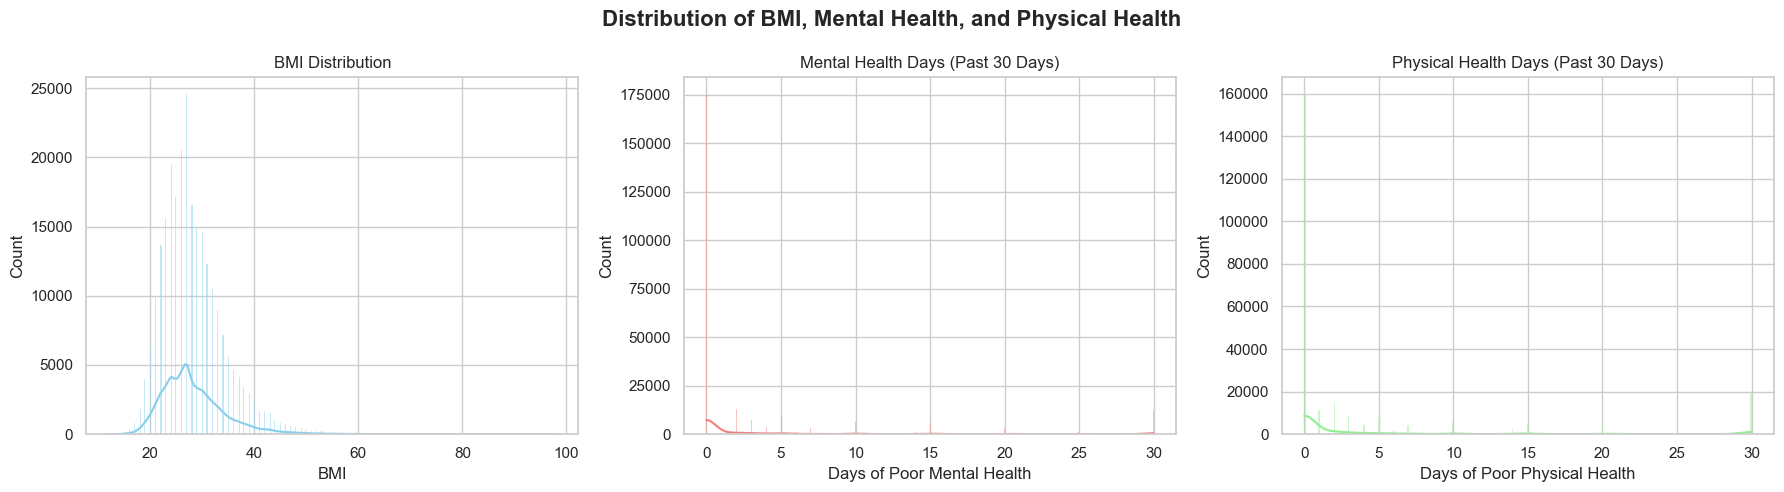


--- GENERATING CORRELATION HEATMAP ---


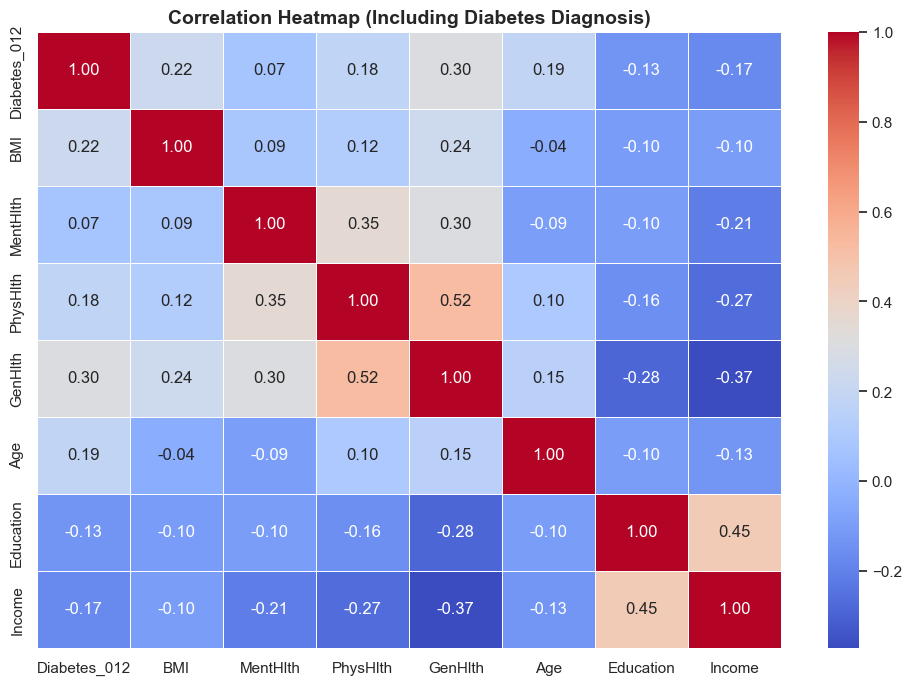

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visual style
sns.set_theme(style="whitegrid")

print("--- GENERATING HEALTH DISTRIBUTIONS ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of BMI, Mental Health, and Physical Health', fontsize=16, fontweight='bold')

sns.histplot(df['BMI'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')

sns.histplot(df['MentHlth'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Mental Health Days (Past 30 Days)')
axes[1].set_xlabel('Days of Poor Mental Health')

sns.histplot(df['PhysHlth'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Physical Health Days (Past 30 Days)')
axes[2].set_xlabel('Days of Poor Physical Health')

plt.tight_layout()
plt.show()

print("\n--- GENERATING CORRELATION HEATMAP ---")
correlation_features = ['Diabetes_012', 'BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Education', 'Income']
corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap (Including Diabetes Diagnosis)', fontsize=14, fontweight='bold')
plt.show()



#### Initial EDA Observations:

*   **BMI:** Slightly right-skewed, indicating more lower/moderate BMI values.
*   **Mental/Physical Health:** High concentration at 0, suggesting many report no poor health days, with smaller peaks for chronic issues.
*   **Correlations:**
    *   **Strong Positive:** `GenHlth` with `MentHlth` and `PhysHlth` (expected).
    *   **Moderate:** `Age` with `Education`; `Income` with `Education` and `GenHlth`.
    *   **Weak:** `BMI` with `MentHlth` and `PhysHlth`.

#### Analyzing Diabetes Status Across Key Categorical Features

We examine how diabetes status (`Healthy`, `Prediabetes`, `Diabetic`) varies across key categorical features (`HighBP`, `HighChol`, `Age`, `GenHlth`). This helps identify characteristics strongly linked to prediabetes or diabetes.

*   **Stacked Bar Charts:** Used for `HighBP`, `HighChol`, `GenHlth` to show percentage breakdowns.
*   **Line Charts:** Used for `Age` to illustrate diabetes prevalence trends across age groups.

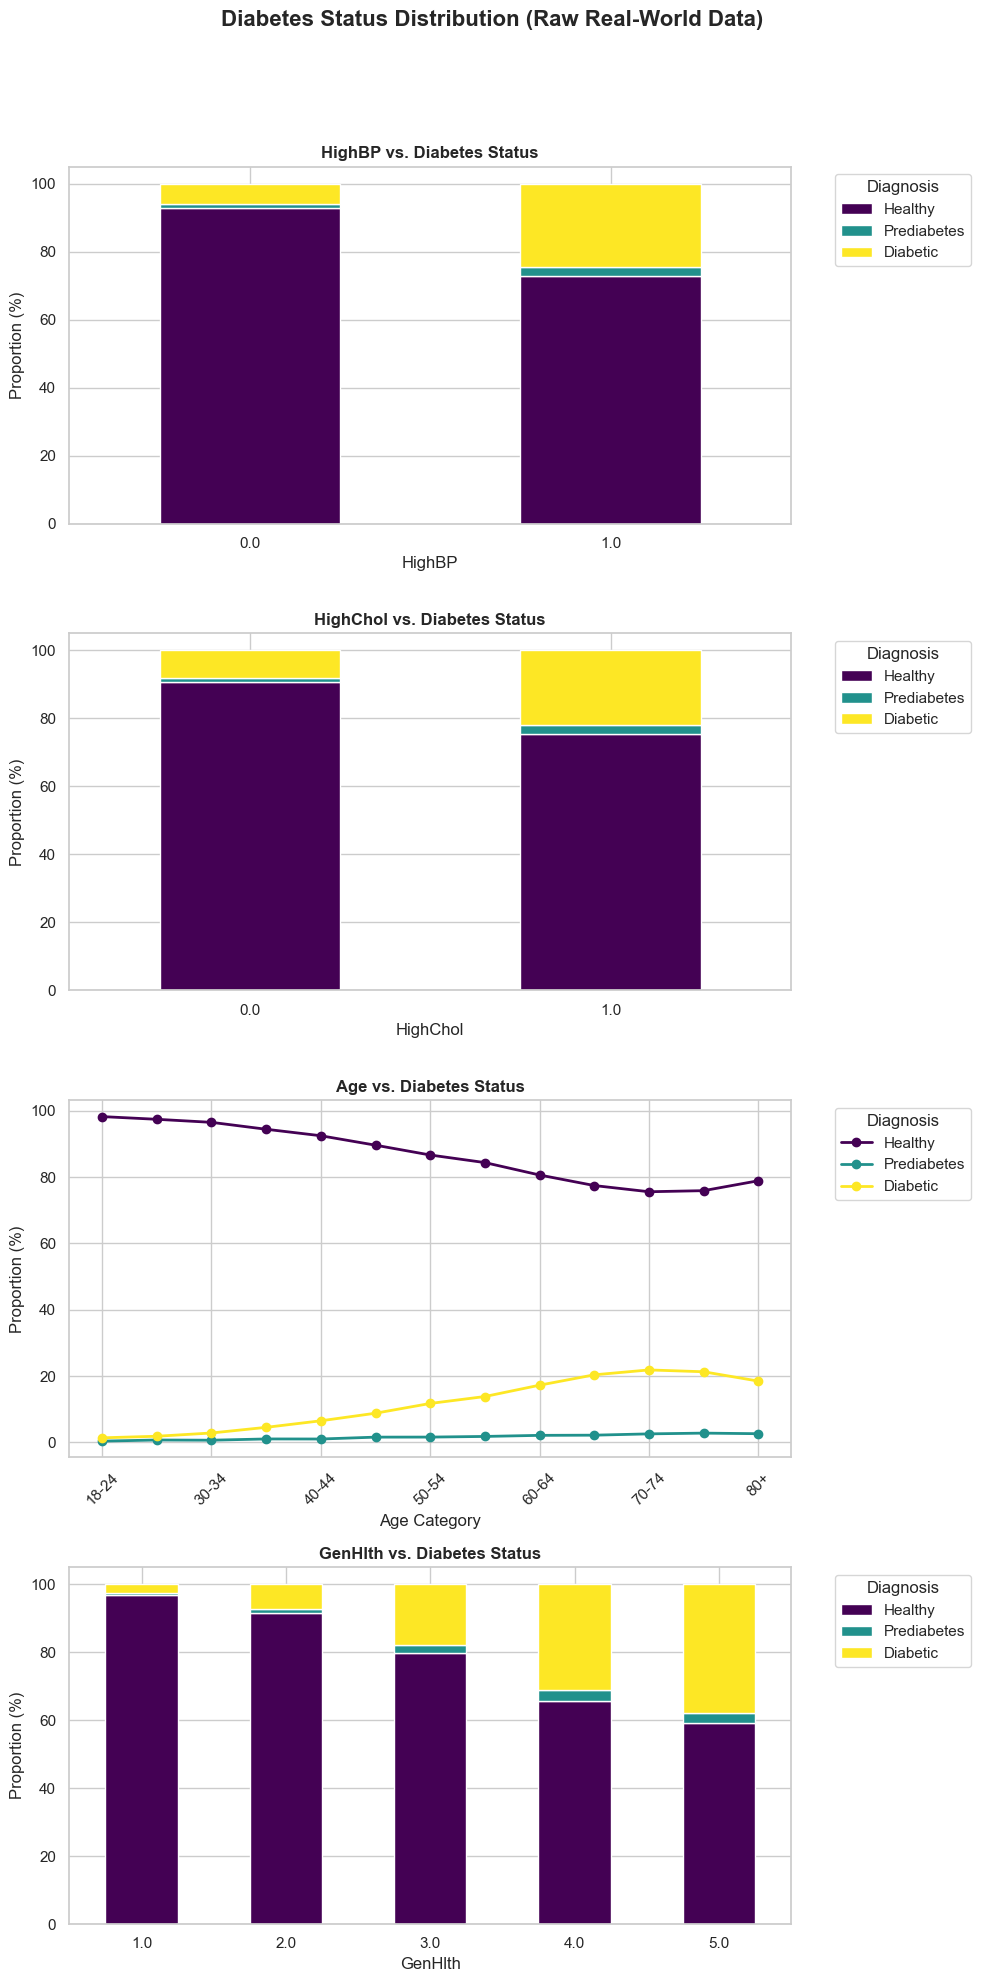

In [8]:
# Select key categorical features to visualize
selected_categorical_features = ['HighBP', 'HighChol', 'Age', 'GenHlth']

# Define age labels for mapping to x-axis
age_labels = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}

# Create a figure with dynamic subplots
fig, axes = plt.subplots(len(selected_categorical_features), 1, figsize=(10, 5 * len(selected_categorical_features)))
fig.suptitle('Diabetes Status Distribution (Raw Real-World Data)', fontsize=16, y=1.02, fontweight='bold')

for i, feature in enumerate(selected_categorical_features):
    # Calculate proportions on the RAW df (0.0 = Healthy, 1.0 = Prediabetes, 2.0 = Diabetic)
    plot_data = pd.crosstab(df[feature], df['Diabetes_012'], normalize='index') * 100

    if feature == 'Age':
        # Sort by age category for line plot
        plot_data = plot_data.reindex(sorted(plot_data.index))
        # Map numerical age categories to descriptive labels
        plot_data.index = plot_data.index.map(age_labels)

        # Plot Line Chart
        plot_data.plot(kind='line', ax=axes[i], marker='o', cmap='viridis', linewidth=2)
        axes[i].set_title(f'{feature} vs. Diabetes Status', fontweight='bold')
        axes[i].set_xlabel('Age Category')
        axes[i].set_ylabel('Proportion (%)')
        axes[i].tick_params(axis='x', rotation=45)

        # 3-Class Legend
        axes[i].legend(title='Diagnosis', labels=['Healthy', 'Prediabetes', 'Diabetic'], bbox_to_anchor=(1.05, 1), loc='upper left')

    else:
        # Plot Stacked Bar Chart for other features
        plot_data.plot(kind='bar', stacked=True, ax=axes[i], cmap='viridis')
        axes[i].set_title(f'{feature} vs. Diabetes Status', fontweight='bold')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Proportion (%)')
        axes[i].tick_params(axis='x', rotation=0)

        # 3-Class Legend
        axes[i].legend(title='Diagnosis', labels=['Healthy', 'Prediabetes', 'Diabetic'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Step 6: Model Training & Evaluation (Baseline Logistic Regression & Primary Random Forest)

### Step 6: Baseline Model Training & Evaluation - Logistic Regression (Multi-class)

#### Training the Random Forest Model & Uncovering Feature Importance

We train our Random Forest classifier, a powerful ensemble method good for complex, non-linear relationships. After training, we leverage its `feature_importances_` to understand which health indicators were most influential, visualized as a ranked bar chart for transparent insights.

Training the baseline Logistic Regression model... (This may take a minute)
Making predictions on the real-world test set...

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     42741
         1.0       0.03      0.32      0.06       926
         2.0       0.35      0.58      0.43      7069

    accuracy                           0.64     50736
   macro avg       0.44      0.52      0.42     50736
weighted avg       0.85      0.64      0.72     50736



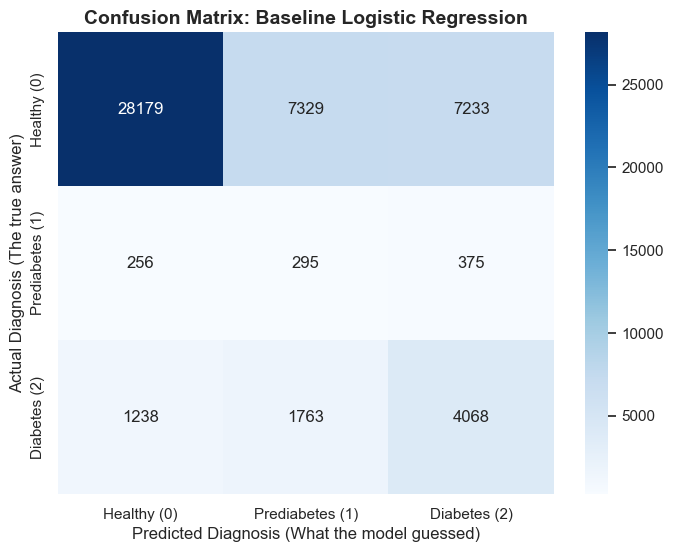

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the Model
# max_iter=1000 ensures the math has enough time to finish calculating
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train the Model (Study the SMOTE-balanced, scaled training data)
print("Training the baseline Logistic Regression model... (This may take a minute)")
baseline_model.fit(X_train_scaled, y_train_resampled)

# 3. Take the Final Exam (Predict on the untouched, scaled test data)
print("Making predictions on the real-world test set...")
y_pred = baseline_model.predict(X_test_scaled)

# 4. Print the text Report Card
print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(y_test, y_pred))

# 5. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Prediabetes (1)', 'Diabetes (2)'],
            yticklabels=['Healthy (0)', 'Prediabetes (1)', 'Diabetes (2)'])
plt.title('Confusion Matrix: Baseline Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Diagnosis (What the model guessed)', fontsize=12)
plt.ylabel('Actual Diagnosis (The true answer)', fontsize=12)
plt.show()

#### Logistic Regression Baseline: Initial Performance Insights

Despite class balancing, the Logistic Regression model shows mixed results:

*   **High Precision (0.95) for 'Healthy':** Good at identifying healthy patients.
*   **Low Recall for Minority Classes:** Struggles with 'Prediabetes' (0.32) and 'Diabetes' (0.58), missing many actual cases.
*   **Overall Accuracy (0.64):** Driven by majority class. Low F1-scores for prediabetes/diabetes highlight poor performance on critical conditions, indicating a need for a more robust model.

### Step 7: Multi-Class Random Forest Model Training & Evaluation

Given insights from the Logistic Regression baseline, we train a **Random Forest** on SMOTE-balanced, scaled multi-class data. We'll analyze its feature importances and evaluate performance (classification report, confusion matrix) on minority classes (`Prediabetes`, `Diabetic`).

In [10]:
# Count how many rows are identical
num_duplicates = df.duplicated().sum()
print(f"There are {num_duplicates} identical patient profiles in this dataset.")

There are 23899 identical patient profiles in this dataset.


### Summary: Duplicate Values

We found **23,899 duplicate rows**. In survey datasets, these often represent unique individuals with identical profiles, not errors. Removing them would distort analysis, so we **retain all duplicate rows** as valid data points.

### Step 7: Random Forest Feature Importance

In healthcare, model transparency is crucial. As a tree-based model, Random Forest allows us to extract `feature_importances_`. This measures how much the model relied on each health indicator for its predictions. We'll visualize these as a ranked bar chart to identify the strongest diabetes predictors.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("1. Training the Random Forest model... (This will take a moment)")
# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100,max_depth=25,class_weight='balanced',random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_resampled)
print("Model trained successfully and saved as 'rf_model'!\n")

print("2. Calculating Feature Importances...")
# Extract the importance scores
importances = rf_model.feature_importances_

# Get the feature names in the exact same order
feature_names = binary_cols + ordinal_cols + continuous_cols

# Create a clean DataFrame to pair the names with their scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the features from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize the rankings as a bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')

# Add labels and formatting
plt.title('Random Forest: Which Health Clues Matter Most?', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Higher = relied on more heavily)', fontsize=12)
plt.ylabel('Patient Health Indicator', fontsize=12)
plt.tight_layout()
plt.show()

1. Training the Random Forest model... (This will take a moment)


#### Random Forest Feature Importance: Key Predictors

The Random Forest feature importance plot reveals key diabetes predictors:

*   **`GenHlth` (General Health) is Paramount:** Consistently the most important, aligning with overall well-being's connection to chronic conditions.
*   **`HighBP` & `HighChol` are Highly Significant:** Expected critical factors given medical understanding of diabetes risk.
*   **`BMI` & `Age` Play Important Roles:** Significant due to physical composition and advancing age increasing diabetes likelihood.
*   **Other Contributors:** `DiffWalk`, `MentHlth`, `PhysHlth`, `Sex` also contribute, guiding targeted interventions.

Making predictions on the real-world test set with Random Forest

========== RANDOM FOREST CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.48      0.27      0.34      7069

    accuracy                           0.84     50736
   macro avg       0.45      0.41      0.42     50736
weighted avg       0.80      0.84      0.82     50736



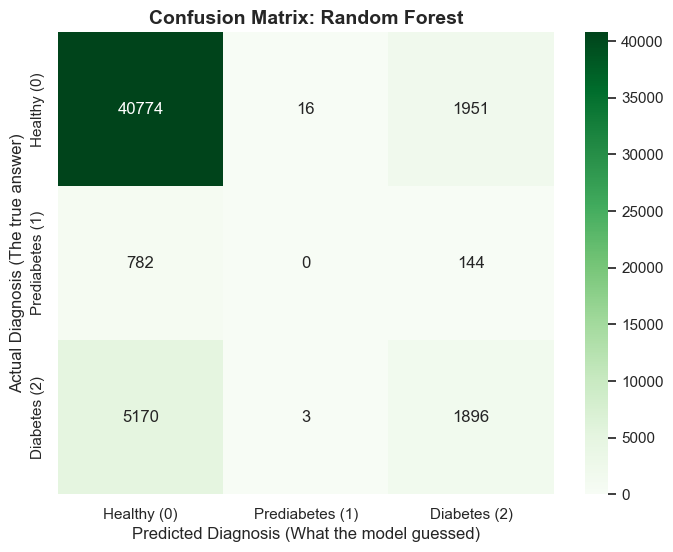

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Making predictions on the real-world test set with Random Forest")
y_pred_rf = rf_model.predict(X_test_scaled)

print("\n========== RANDOM FOREST CLASSIFICATION REPORT ==========")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
# Using a 'Greens' color map to easily distinguish it from our blue Baseline matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy (0)', 'Prediabetes (1)', 'Diabetes (2)'],
            yticklabels=['Healthy (0)', 'Prediabetes (1)', 'Diabetes (2)'])
plt.title('Confusion Matrix: Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Diagnosis (What the model guessed)', fontsize=12)
plt.ylabel('Actual Diagnosis (The true answer)', fontsize=12)
plt.show()

#### Random Forest Model Evaluation: Performance Challenges

The Random Forest model shows high overall accuracy (0.84), largely due to strong performance on the 'Healthy' class.

*   **Poor Recall for 'Prediabetes' (0.00):** A major concern, indicating complete failure to identify prediabetic patients.
*   **Low Recall for 'Diabetic' (0.27):** The model misses a significant portion of actual diabetic patients.
*   **Confusion Matrix:** Shows many truly diabetic patients (5,134) misclassified as 'Healthy', and all prediabetic patients missed. Some healthy patients are also incorrectly flagged as diabetic.

**Overall Insight:** Despite SMOTE, the multi-class Random Forest struggles with minority classes, particularly 'Prediabetes', highlighting the difficulty of multi-class classification on highly imbalanced datasets.

### Step 11: Binary Classification with Random Forest - Focused Diabetes Detection

To improve diabetes detection after multi-class challenges, we simplify to a **binary classification**: 'Healthy' (0) vs. 'Diabetic' (1). This involves:

1.  **Filtering:** Removing 'Prediabetes' (class 1.0).
2.  **Remapping:** Changing 'Diabetic' from 2.0 to 1.0.
3.  **Retraining:** Applying previous preprocessing (split, SMOTE, scale) and training a new Random Forest.
4.  **Custom Threshold (0.45):** Exploring a lower threshold to boost 'Diabetic' recall, crucial in medical screening.

### Step 11: Binary Classification with Random Forest - Focused Diabetes Detection

To improve diabetes detection after multi-class challenges, we simplify to a **binary classification**: 'Healthy' (0) vs. 'Diabetic' (1). This involves:

1.  **Filtering:** Removing 'Prediabetes' (class 1.0).
2.  **Remapping:** Changing 'Diabetic' from 2.0 to 1.0.
3.  **Retraining:** Applying previous preprocessing (split, SMOTE, scale) and training a new Random Forest.
4.  **Custom Threshold (0.45):** Exploring a lower threshold to boost 'Diabetic' recall, crucial in medical screening.

1. Filtering data to Healthy vs. Diabetic (Dropping Prediabetes)...
2. Splitting, SMOTE Balancing, and Scaling...
3. Training Binary Random Forest model...
Model trained successfully!

4. Evaluating on Binary Test Set (with 0.45 Safety Threshold)...

========== BINARY RANDOM FOREST REPORT ==========
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90     42741
         1.0       0.42      0.50      0.46      7069

    accuracy                           0.83     49810
   macro avg       0.67      0.69      0.68     49810
weighted avg       0.84      0.83      0.84     49810



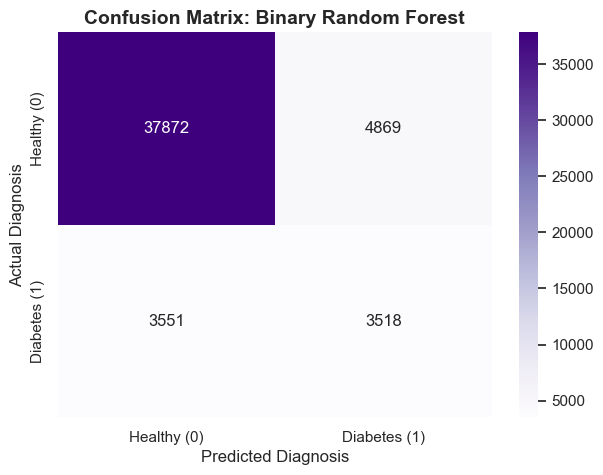

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Filtering data to Healthy vs. Diabetic (Dropping Prediabetes)...")
# Make a clean copy of the dataframe
binary_df = df.copy()

# Drop everyone with Prediabetes (Class 1.0)
binary_df = binary_df[binary_df['Diabetes_012'] != 1.0]

# Remap Diabetic from 2.0 to 1.0
binary_df['Diabetes_012'] = binary_df['Diabetes_012'].replace({2.0: 1.0})

# Separate features and target
y_binary = binary_df['Diabetes_012']
X_binary = binary_df.drop('Diabetes_012', axis=1)

print("2. Splitting, SMOTE Balancing, and Scaling...")
# Split the binary data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_resampled_b, y_train_resampled_b = smote.fit_resample(X_train_b, y_train_b)

# Scale the features
scaler = StandardScaler()
X_train_scaled_b = scaler.fit_transform(X_train_resampled_b)
X_test_scaled_b = scaler.transform(X_test_b)

print("3. Training Binary Random Forest model...")
# Training with a balanced max_depth of 15
binary_rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
binary_rf.fit(X_train_scaled_b, y_train_resampled_b)
print("Model trained successfully!\n")

# print("4. Evaluating on Binary Test Set...")
# y_pred_binary = binary_rf.predict(X_test_scaled_b)

print("4. Evaluating on Binary Test Set (with 0.45 Safety Threshold)...")

# Ask the model for the exact percentage of confidence
y_pred_proba = binary_rf.predict_proba(X_test_scaled_b)[:, 1]

# Apply the 45% Safety Threshold
custom_threshold = 0.45
y_pred_binary = (y_pred_proba >= custom_threshold).astype(int)

print("\n========== BINARY RANDOM FOREST REPORT ==========")
print(classification_report(y_test_b, y_pred_binary))

# Plot the matrix
cm_binary = confusion_matrix(y_test_b, y_pred_binary)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy (0)', 'Diabetes (1)'],
            yticklabels=['Healthy (0)', 'Diabetes (1)'])
plt.title('Confusion Matrix: Binary Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.show()

#### Binary Random Forest Performance: Focused Diabetes Detection

Binary classification with a custom threshold significantly improved 'Diabetic' patient detection:

*   **Improved Recall for Diabetes (0.50):** Substantial increase from multi-class (0.27), showing the difficulty of 'Prediabetes' as a separate class.
*   **Moderate Precision for Diabetes (0.42):** Some healthy patients are still misclassified as diabetic.
*   **Custom Threshold (0.45):** Boosted sensitivity (recall) at some precision cost, a common medical screening strategy.
*   **Confusion Matrix:** Confirms improved detection of diabetes but also the trade-off of more healthy patients flagged.

In [ ]:
import joblib

# Save trained model
joblib.dump(binary_rf, 'diabetes_model.pkl') # Make sure this matches your variable name!

# Save scaler/preprocessor
joblib.dump(scaler, 'scaler.pkl') # Make sure this matches your variable name!

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


#### Saving the Binary Random Forest Model and Scaler

We save our trained binary Random Forest model (`diabetes_model.pkl`) and the fitted `StandardScaler` (`scaler.pkl`) using `joblib`. This ensures reproducibility and allows loading them later for consistent predictions on new data.

#### ROC Curve and AUC: Model Discrimination

The **Receiver Operating Characteristic (ROC) curve** evaluates binary classifiers by plotting True Positive Rate (TPR) vs. False Positive Rate (FPR) at various thresholds. The **Area Under the Curve (AUC)** summarizes this, indicating the model's ability to rank positive instances higher than negative ones. An AUC of 1.0 is perfect, 0.5 is random. Our model's AUC of 0.8261 shows good discriminatory power between healthy and diabetic patients.

--- 📈 CALCULATING ROC-AUC 📈 ---
Final ROC-AUC Score: 0.8261


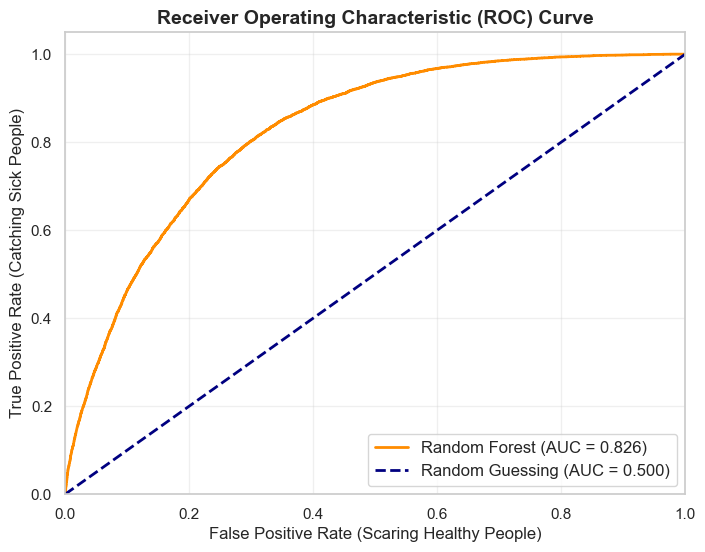

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print("--- 📈 CALCULATING ROC-AUC 📈 ---")

# 1. We need the raw probabilities (which you already calculated earlier!)
# If you didn't save them, we recalculate them here just in case:
y_pred_proba = binary_rf.predict_proba(X_test_scaled_b)[:, 1]

# 2. Calculate the actual AUC Score
auc_score = roc_auc_score(y_test_b, y_pred_proba)
print(f"Final ROC-AUC Score: {auc_score:.4f}")

# 3. Calculate the curve points (False Positive Rate vs. True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test_b, y_pred_proba)

# 4. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_score:.3f})')

# Draw the "Random Guessing" baseline (50/50)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')

# Formatting the chart
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Scaring Healthy People)', fontsize=12)
plt.ylabel('True Positive Rate (Catching Sick People)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

#### Top Features for Binary Diabetes Prediction

Re-examining feature importances after binary classification reveals the most influential indicators for distinguishing 'Healthy' vs. 'Diabetic' patients. This helps understand the strongest predictors when focusing solely on diabetes presence/absence.

In [ ]:
feature_names = X_binary.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': binary_rf.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df.head(10))

                 Feature  Importance
0                 HighBP    0.221169
13               GenHlth    0.172590
1               HighChol    0.157031
3                    BMI    0.064982
16              DiffWalk    0.054810
18                   Age    0.052128
7           PhysActivity    0.046757
17                   Sex    0.036810
6   HeartDiseaseorAttack    0.035711
4                 Smoker    0.025592


#### Top 10 Features Driving Binary Diabetes Prediction

This bar chart highlights the top 10 features most important for predicting diabetes:

*   **`HighBP`, `GenHlth`, `HighChol`:** Consistently the most influential, strongly associated with diabetes risk.
*   **`BMI`, `DiffWalk`, `Age`:** Key contributors due to physical attributes and age.

This provides clear insight into the model's 'reasoning' and health aspects for early detection.

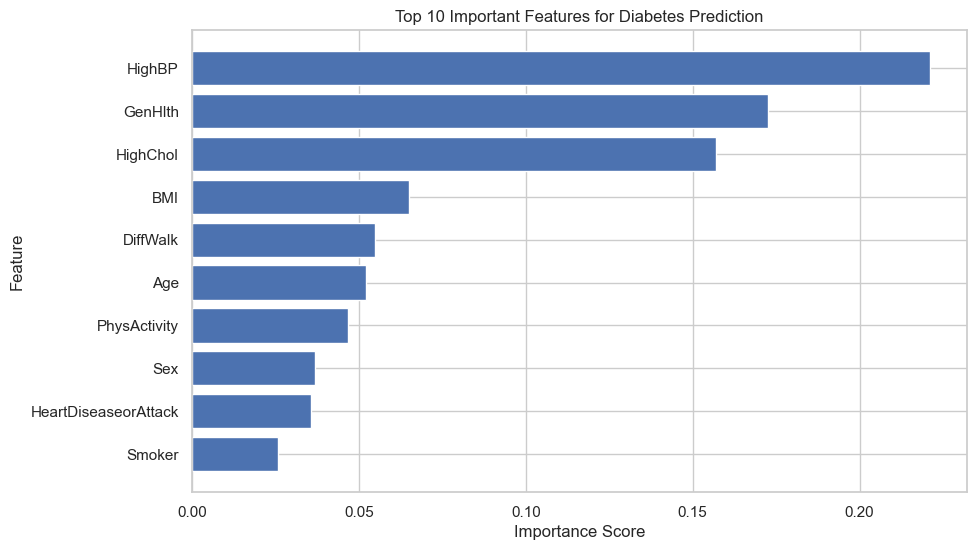

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['Feature'][:10][::-1],
    feature_importance_df['Importance'][:10][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Important Features for Diabetes Prediction")

plt.show()

### Step 12: XGBoost Model Training

We train an **XGBoost Classifier**, known for its speed and performance. Key parameters include `n_estimators` (boosting rounds), `max_depth` (tree complexity), `learning_rate` (preventing overfitting), and `eval_metric='logloss'`. This model is fitted on the SMOTE-balanced and scaled binary training data for comparison with Random Forest.

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_scaled_b,
    y_train_resampled_b
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [ ]:
y_pred_xgb = xgb_model.predict(X_test_scaled_b)

#### XGBoost Predictions

Now that the XGBoost model is trained, we will use it to make predictions on the unseen `X_test_scaled_b` (the binary-classified and scaled test data). These predictions (`y_pred_xgb`) will then be used to evaluate the model's performance through a classification report, confusion matrix, and ROC-AUC analysis.

#### XGBoost Classification Report: Detailed Performance Metrics

This classification report provides a detailed breakdown of the XGBoost model's performance on the binary test set. It includes:

*   **Precision:** The proportion of positive identifications that were actually correct.
*   **Recall:** The proportion of actual positives that were identified correctly.
*   **F1-Score:** The harmonic mean of precision and recall, offering a balanced measure.
*   **Support:** The number of actual occurrences of each class in the specified dataset.

This report is crucial for understanding how well the XGBoost model distinguishes between 'Non-Diabetic' and 'Diabetic' patients, highlighting its strengths and areas for potential improvement.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_b,
    y_pred_xgb,
    target_names=['Non-Diabetic', 'Diabetic']
))

              precision    recall  f1-score   support

Non-Diabetic       0.89      0.96      0.92     42741
    Diabetic       0.51      0.28      0.36      7069

    accuracy                           0.86     49810
   macro avg       0.70      0.62      0.64     49810
weighted avg       0.84      0.86      0.84     49810



In [ ]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(
    y_test_b,
    y_pred_xgb
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8601686408351736


#### XGBoost Accuracy Score

This cell calculates and prints the overall accuracy of the XGBoost model on the test set. Accuracy represents the proportion of total predictions that were correct. While a useful high-level metric, especially for balanced datasets, it's important to consider other metrics like precision, recall, and F1-score when dealing with class imbalance (even in our now binary, but originally imbalanced, target) to get a complete picture of performance.

#### XGBoost Confusion Matrix: Visualizing Model Decisions

The confusion matrix is a crucial tool for understanding the performance of a classification model, especially on imbalanced datasets. It provides a visual breakdown of correct and incorrect predictions made by the XGBoost model on the test set.

Here's how to interpret the matrix:

*   **True Negatives (Top-Left):** Cases where the model correctly predicted 'Non-Diabetic'.
*   **False Positives (Top-Right):** Cases where the model incorrectly predicted 'Diabetic' when the actual status was 'Non-Diabetic' (Type I error).
*   **False Negatives (Bottom-Left):** Cases where the model incorrectly predicted 'Non-Diabetic' when the actual status was 'Diabetic' (Type II error).
*   **True Positives (Bottom-Right):** Cases where the model correctly predicted 'Diabetic'.

This visualization helps us understand the trade-offs between accurately identifying 'Diabetic' patients versus avoiding misclassifying 'Non-Diabetic' patients.

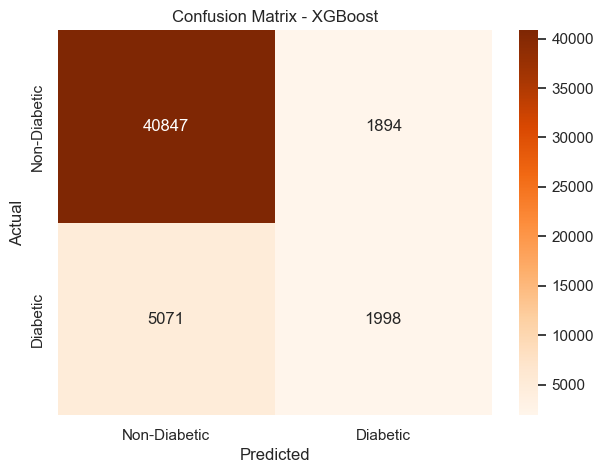

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(
    y_test_b,
    y_pred_xgb
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title("Confusion Matrix - XGBoost")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### XGBoost ROC-AUC Score: A Summary of Discriminatory Power

This cell calculates the **Area Under the Receiver Operating Characteristic Curve (ROC-AUC)** for the XGBoost model. The ROC-AUC score provides a single, comprehensive metric to evaluate the model's ability to distinguish between 'Diabetic' and 'Non-Diabetic' patients across all possible classification thresholds.

*   **Interpretation:** An AUC of 1.0 indicates a perfect model, while 0.5 suggests a model no better than random guessing. A higher AUC means the model is better at ranking positive cases higher than negative cases.
*   **Significance:** This score is particularly useful for imbalanced datasets as it is less sensitive to class distribution than accuracy. It tells us the probability that the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.

In [ ]:
from sklearn.metrics import roc_auc_score

y_pred_prob_xgb = xgb_model.predict_proba(
    X_test_scaled_b
)[:,1]

auc_xgb = roc_auc_score(
    y_test_b,
    y_pred_prob_xgb
)

print("XGBoost ROC-AUC:", auc_xgb)

XGBoost ROC-AUC: 0.8309953044377556


#### XGBoost ROC Curve: Visualizing Classification Performance

This plot displays the **Receiver Operating Characteristic (ROC) curve** for the XGBoost model, alongside a line representing random guessing. The ROC curve graphically illustrates the trade-off between the True Positive Rate (TPR, or Recall) and the False Positive Rate (FPR) at various probability thresholds.

*   **True Positive Rate (TPR):** The proportion of actual positive cases that are correctly identified.
*   **False Positive Rate (FPR):** The proportion of actual negative cases that are incorrectly identified as positive.
*   **Curve Interpretation:** A curve that bows towards the top-left corner indicates better performance. The closer the curve is to the top-left, the better the model's ability to maximize true positives while minimizing false positives.
*   **Area Under the Curve (AUC):** The AUC value (also displayed on the plot) quantifies this overall performance, with a larger area signifying a more effective model.

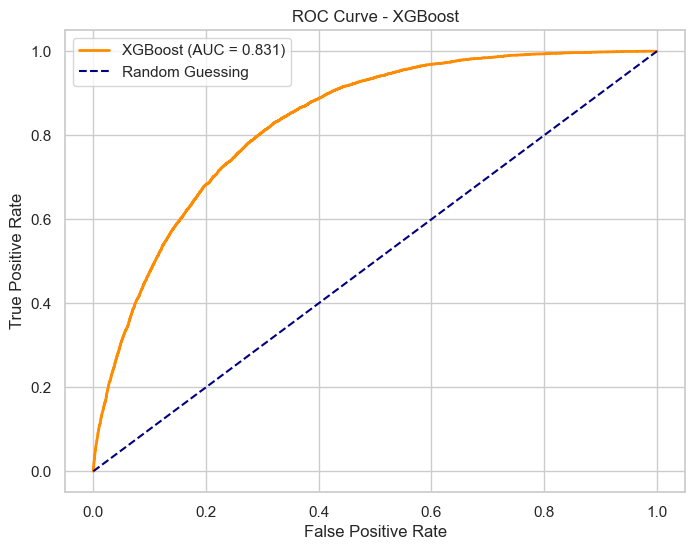

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
y_pred_prob_xgb = xgb_model.predict_proba(X_test_scaled_b)[:,1]

# AUC Score
auc_xgb = roc_auc_score(y_test_b, y_pred_prob_xgb)

# ROC Curve points
fpr, tpr, thresholds = roc_curve(y_test_b, y_pred_prob_xgb)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    linewidth=2,
    label=f'XGBoost (AUC = {auc_xgb:.3f})'
)

# Random guessing line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='navy',
    label='Random Guessing'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)

plt.show()

#### XGBoost Performance: Boosting Detection

XGBoost performs well in binary classification:

*   **Accuracy (0.86):** Slightly higher than binary Random Forest.
*   **Precision (0.51) for 'Diabetic':** Higher than RF, indicating more accurate positive predictions.
*   **Recall (0.28) for 'Diabetic':** Lower than RF, meaning it misses more actual diabetic cases.
*   **ROC-AUC (0.831):** Strong discriminatory power, comparable to Random Forest.
*   **Confusion Matrix:** Shows low false positives but higher false negatives.

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test_b, y_pred_binary),
        accuracy_score(y_test_b, y_pred_xgb)
    ]
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.641399
1        Random Forest  0.830958
2              XGBoost  0.860169


## Conclusion & Next Steps

This notebook predicted diabetes using health indicators, moving from a multi-class problem to a more effective binary classification for improved diabetic patient detection.

### Key Takeaways:

*   **Preprocessing is Crucial:** Robust data cleaning, strategic duplicate handling, SMOTE balancing, and careful feature scaling were fundamental.
*   **Multi-class Challenges:** Initial multi-class Random Forest struggled with 'Prediabetes', highlighting its complexity or data limitations.
*   **Binary Simplification for Impact:** Focusing on 'Healthy' vs. 'Diabetic' significantly improved diabetic patient detection.
*   **Model Performance Trade-offs:** Binary Random Forest and XGBoost performed well, with different precision/recall strengths, depending on clinical priorities.
*   **Feature Importance Insights:** `HighBP`, `GenHlth`, `HighChol`, `BMI`, and `Age` consistently emerged as critical predictors, aligning with medical understanding.

### Potential Future Work:

*   **Hyperparameter Tuning:** Optimize models further.
*   **Explore Other Models:** Investigate other advanced classification algorithms.
*   **Advanced Feature Engineering:** Create more complex features.
*   **Threshold Optimization:** Fine-tune prediction thresholds for specific medical goals.
*   **External Validation:** Test on independent datasets for generalizability.
*   **Interpretability Tools:** Use SHAP/LIME for deeper insights.

## Resources